In [1]:
from pathlib import Path
import sys, os

scriptPath = Path.cwd()
parentPath = scriptPath.parent
dataPath = parentPath / 'data'
srcPath = parentPath / 'src'
modelPath = parentPath / 'models'
savePath = parentPath / 'results'
plotPath = parentPath / 'plots'

sys.path.append(srcPath.as_posix())

# MMF MNIST
## Load the data

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

class ScatterTransform:
    """
    Simulate scattering (e.g. through a multimode fiber) by:
    1. Computing the FFT of the input image.
    2. Multiplying by a fixed random phase mask.
    3. Computing the inverse FFT and taking the squared magnitude.
    This yields a speckle intensity pattern.
    """
    def __init__(self, image_size=(28, 28), seed=42):
        self.image_size = image_size
        torch.manual_seed(seed)
        # Create a random phase mask (fixed for all images)
        phi = torch.rand(image_size) * 2 * torch.pi
        self.scattering_mask = torch.exp(1j * phi)

    def __call__(self, image):
        # image is expected to be a tensor of shape (C, H, W); FashionMNIST is grayscale (C=1)
        # Convert to 2D by removing the channel dimension
        image_2d = image[:]
        # Apply FFT to the image
        image_fft = torch.fft.fft2(image_2d)
        # Multiply by the fixed scattering mask
        scattered_fft = image_fft * self.scattering_mask.to(image_fft.device)
        # Compute the inverse FFT to get the scattered field
        scattered_field = torch.fft.ifft2(scattered_fft)
        # Compute the speckle intensity (absolute squared)
        speckle = torch.abs(scattered_field) ** 2
        # Normalize to [0, 1] for stability
        speckle = (speckle - speckle.min()) / (speckle.max() - speckle.min() + 1e-8)
        # Return as a 1-channel image
        return speckle.unsqueeze(1)

In [3]:
# Hyperparameters
batch_size = 128
image_size = 28
num_classes = 10

# Data transforms
transform = transforms.ToTensor()

# Load datasets
train_dataset = datasets.MNIST(root=dataPath, train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root=dataPath, train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [4]:
scatter_transform = ScatterTransform(image_size=(image_size, image_size), seed=42)

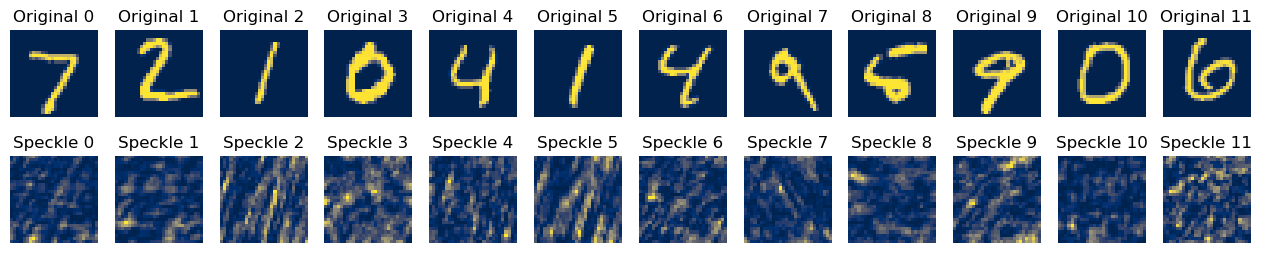

In [5]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = sns.color_palette("cividis", as_cmap=True)
fig, axes = plt.subplots(2, 12, figsize=(16, 3))

for i in range(12):
  # ind = np.random.randint(0, len(test_dataset))
  ind = i
  original_tensor, label = test_dataset[ind]
  speckle_image = scatter_transform(original_tensor.unsqueeze(0))
  axes[0,i].imshow(original_tensor.squeeze(), cmap=cm)
  axes[0,i].set_title(f'Original {i}')
  axes[0,i].axis('off')

  axes[1,i].imshow(speckle_image.squeeze(), cmap=cm)
  axes[1,i].set_title(f'Speckle {i}')
  axes[1,i].axis('off')

## Classification

In [6]:
from PANS_linear import PANS_passive

device = 'cpu'
MMFclassPath = modelPath / 'MMF_MNIST_classification'

models = {}
dfs = []
for f in os.listdir(MMFclassPath):
    if f.startswith(f'Trans42MNIST_N'):
        N = int(f.split('_')[1][1:])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_passive(n_input=image_size**2, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(MMFclassPath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

16 Trans42MNIST_N16_fc[512].pth
5 Trans42MNIST_N5_fc[512].pth
24 Trans42MNIST_N24_fc[512].pth
10 Trans42MNIST_N10_fc[512].pth
32 Trans42MNIST_N32_fc[512].pth
6 Trans42MNIST_N6_fc[512].pth
8 Trans42MNIST_N8_fc[512].pth
4 Trans42MNIST_N4_fc[512].pth
64 Trans42MNIST_N64_fc[512].pth


[4, 5, 6, 8, 10, 16, 24, 32, 64]

In [7]:
import pandas as pd

n_T = 100
temp_results = []

for dcr in [0.01,0.05,0.1]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        acc_arr = np.zeros((n_T))
        for data, target in test_loader:
            data = scatter_transform(data).to(device).reshape(data.shape[0],-1)
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = model.robust_test(data,dcr=dcr,n_rep=1)
                pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct = pred.eq(target.data.view_as(pred)).cpu().sum()
                acc_arr[j] += correct

        acc_arr = acc_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = 100. * acc_arr.mean()
        std_dev = 100. * acc_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})

        print(f"Photon count {photon_count:.4g} \t{np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}% (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0.01
Photon count 2.352 	64.98 ± 0.35% (dcr 0.01, repeat 100)
Photon count 2.917 	70.01 ± 0.38% (dcr 0.01, repeat 100)
Photon count 3.544 	72.90 ± 0.34% (dcr 0.01, repeat 100)
Photon count 4.837 	77.30 ± 0.28% (dcr 0.01, repeat 100)
Photon count 5.892 	80.97 ± 0.31% (dcr 0.01, repeat 100)
Photon count 9.462 	86.05 ± 0.24% (dcr 0.01, repeat 100)
Photon count 14.97 	89.28 ± 0.24% (dcr 0.01, repeat 100)
Photon count 19.81 	91.06 ± 0.21% (dcr 0.01, repeat 100)
Photon count 42.13 	94.00 ± 0.17% (dcr 0.01, repeat 100)

Dark Count Rate:	 0.05
Photon count 2.525 	61.57 ± 0.31% (dcr 0.05, repeat 100)
Photon count 3.111 	66.68 ± 0.36% (dcr 0.05, repeat 100)
Photon count 3.778 	70.14 ± 0.35% (dcr 0.05, repeat 100)
Photon count 5.177 	74.86 ± 0.33% (dcr 0.05, repeat 100)
Photon count 6.286 	78.79 ± 0.32% (dcr 0.05, repeat 100)
Photon count 10.08 	84.49 ± 0.28% (dcr 0.05, repeat 100)
Photon count 15.91 	88.23 ± 0.23% (dcr 0.05, repeat 100)
Photon count 21.09 	90.29 ± 0.26% (dcr 0

In [8]:
results_df.to_pickle(savePath / 'MMF_MNIST_classification_passive_sim.npy')
results_df

,d_f,dcr,mean_accuracy,std_dev,det_photon_count
0,4,0.01,64.9766,0.354218,2.3516
1,5,0.01,70.0142,0.378638,2.9167
2,6,0.01,72.8960,0.344999,3.5440
3,8,0.01,77.3018,0.277782,4.8367
4,10,0.01,80.9662,0.305132,5.8921
5,16,0.01,86.0503,0.237008,9.4620
6,24,0.01,89.2761,0.239357,14.9653
7,32,0.01,91.0616,0.214284,19.8082
8,64,0.01,93.9969,0.169981,42.1269
9,4,0.05,61.5657,0.309707,2.5254


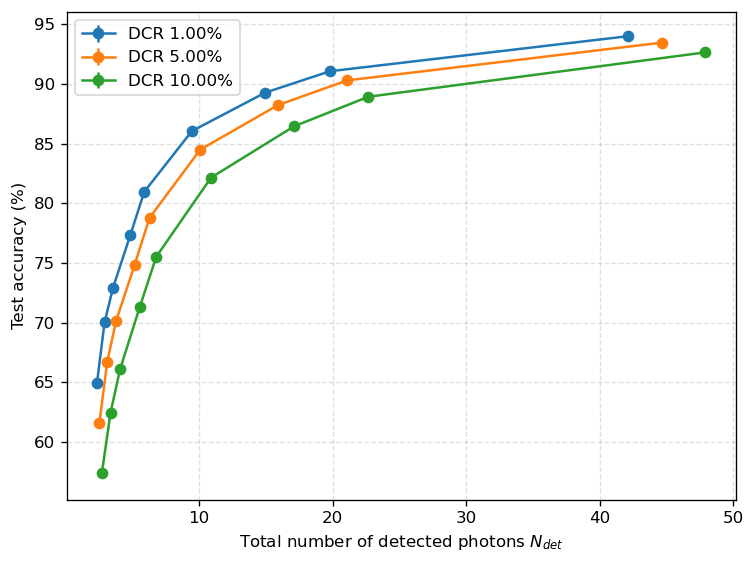

In [9]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_accuracy'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

## Reconstruction

In [10]:
from PANS_linear import PANS_passive

device = 'cpu'
MMFclassPath = modelPath / 'MMF_MNIST_generative'

models = {}
dfs = []
for f in os.listdir(MMFclassPath):
    if f.startswith(f'MMF_MNIST_trans42_recon_N'):
        N = int(f.split('_')[4][1:])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512,512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_passive(n_input=image_size**2, n_output=image_size**2, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(MMFclassPath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

32 MMF_MNIST_trans42_recon_N32_fc[512, 512].pth
48 MMF_MNIST_trans42_recon_N48_fc[512, 512].pth
6 MMF_MNIST_trans42_recon_N6_fc[512, 512].pth
8 MMF_MNIST_trans42_recon_N8_fc[512, 512].pth
64 MMF_MNIST_trans42_recon_N64_fc[512, 512].pth
4 MMF_MNIST_trans42_recon_N4_fc[512, 512].pth
10 MMF_MNIST_trans42_recon_N10_fc[512, 512].pth


[4, 6, 8, 10, 32, 48, 64]

In [11]:
import pandas as pd
from SSIM import ssim

n_T = 10
temp_results = []

for dcr in [0.01,0.05,0.1]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        ssim_arr = np.zeros((n_T))
        for data, target in test_loader:
            original_data = data
            data = scatter_transform(data).to(device).reshape(data.shape[0],-1)
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = torch.sigmoid(model.robust_test(data,dcr=dcr,n_rep=1))
                output = output.view(output.size(0), 1, 28, 28) 
                batch_ssim = ssim(output, original_data , window_size=11, size_average=True)
                ssim_arr[j] += batch_ssim.item() * data.size(0)
            # break

        ssim_arr = ssim_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = ssim_arr.mean()
        std_dev = ssim_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_ssim': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})

        print(f"Photon count {photon_count:.4g} \t{mean_acc:.4f} ± {std_dev:.4f} (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0.01
Photon count 2.156 	0.5777 ± 0.0003 (dcr 0.01, repeat 10)
Photon count 3.364 	0.6149 ± 0.0004 (dcr 0.01, repeat 10)
Photon count 4.493 	0.6420 ± 0.0005 (dcr 0.01, repeat 10)
Photon count 5.669 	0.6637 ± 0.0007 (dcr 0.01, repeat 10)
Photon count 16.39 	0.7679 ± 0.0005 (dcr 0.01, repeat 10)
Photon count 24.65 	0.8006 ± 0.0003 (dcr 0.01, repeat 10)
Photon count 32.19 	0.8196 ± 0.0005 (dcr 0.01, repeat 10)

Dark Count Rate:	 0.05
Photon count 2.315 	0.5695 ± 0.0011 (dcr 0.05, repeat 10)
Photon count 3.598 	0.6034 ± 0.0008 (dcr 0.05, repeat 10)
Photon count 4.809 	0.6300 ± 0.0004 (dcr 0.05, repeat 10)
Photon count 6.078 	0.6495 ± 0.0007 (dcr 0.05, repeat 10)
Photon count 17.66 	0.7540 ± 0.0006 (dcr 0.05, repeat 10)
Photon count 26.49 	0.7871 ± 0.0007 (dcr 0.05, repeat 10)
Photon count 34.77 	0.8082 ± 0.0005 (dcr 0.05, repeat 10)

Dark Count Rate:	 0.1
Photon count 2.51 	0.5594 ± 0.0008 (dcr 0.1, repeat 10)
Photon count 3.898 	0.5903 ± 0.0009 (dcr 0.1, repeat 10)
Phot

In [12]:
results_df.to_pickle(savePath / 'MMF_MNIST_ssim_passive_sim.npy')
results_df

,d_f,dcr,mean_ssim,std_dev,det_photon_count
0,4,0.01,0.577745,0.000305,2.1562
1,6,0.01,0.614880,0.000398,3.3636
2,8,0.01,0.642046,0.000496,4.4930
3,10,0.01,0.663657,0.000730,5.6694
4,32,0.01,0.767857,0.000527,16.3881
5,48,0.01,0.800645,0.000281,24.6501
6,64,0.01,0.819607,0.000518,32.1925
7,4,0.05,0.569496,0.001052,2.3151
8,6,0.05,0.603352,0.000780,3.5977
9,8,0.05,0.630010,0.000393,4.8091


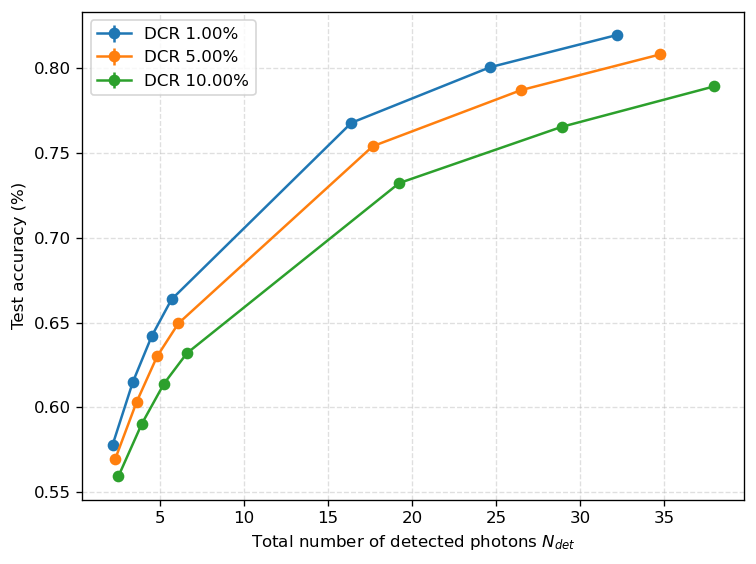

In [13]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_ssim'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# Transient
## Load the data

In [14]:
data = np.load(dataPath / 'transient_4k1k.npz')
X = torch.from_numpy(data['X'])
y = torch.from_numpy(data['y'])
X.shape, y.shape

(torch.Size([5000, 1, 64, 64]), torch.Size([5000]))

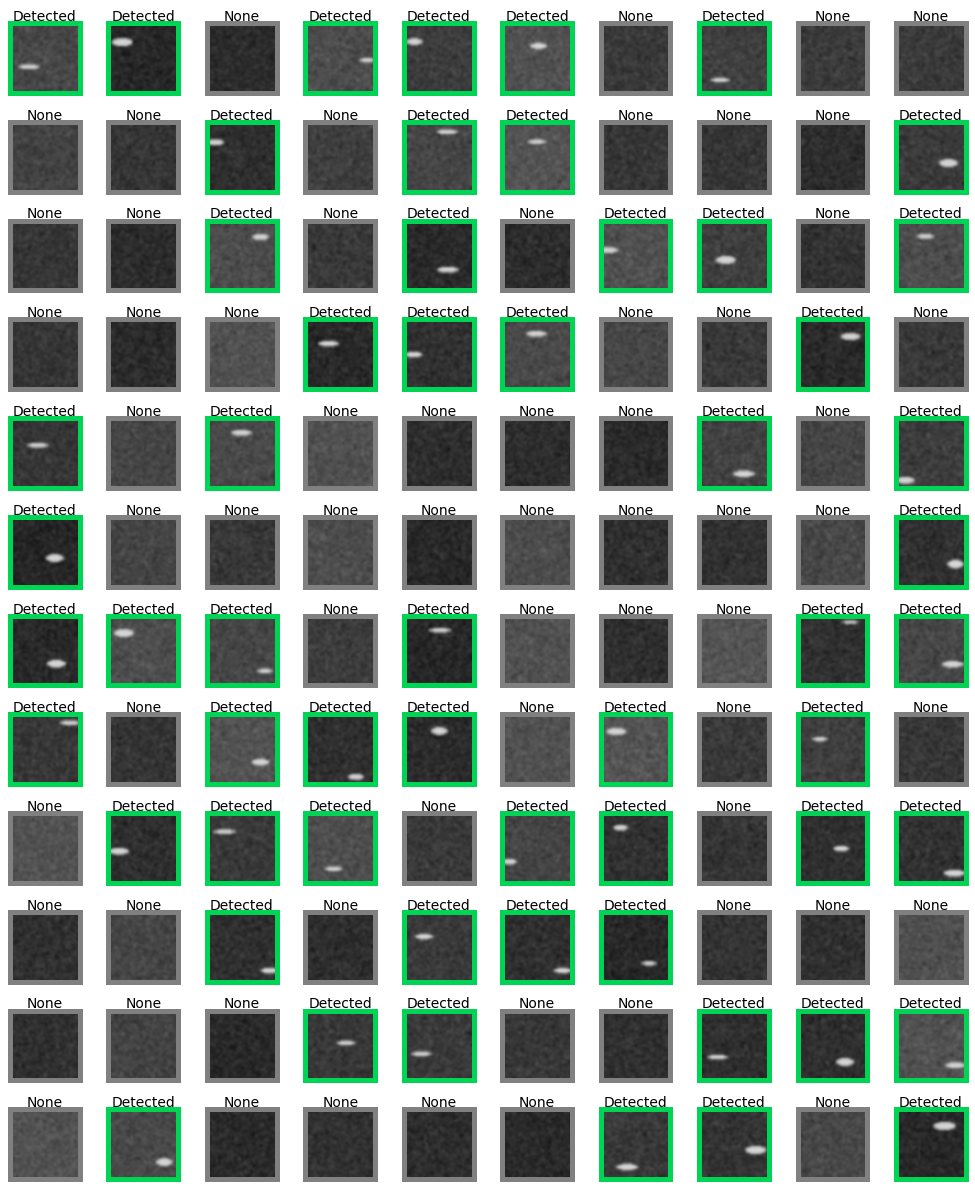

In [15]:
from matplotlib import rcParams
rcParams['axes.titlepad'] = 0 
np.random.seed(10)

nx, ny = 12,10
fig, axs = plt.subplots(nx, ny, figsize=(ny, nx))
namestr = ['None', 'Detected']
for i in range(nx):
    for j in range(ny):
        ax = axs[i, j]
        ind = np.random.randint(X.shape[0])
        im = ax.imshow(X[ind].reshape(64,64), vmin=0, vmax=1.2,cmap='binary_r',aspect='equal')
            
        ax.set_xticks([])
        ax.set_yticks([])
        
        for sp in ax.spines:
            ax.spines[sp].set_color('#00d455' if y[ind] else 'gray')
            ax.spines[sp].set_linewidth(3.6)

        ax.set_title(f'{namestr[y[ind]]}',fontsize=10)

# cb_ax = fig.add_axes([0.93, 0.105, 0.02, 0.8])
# cbar = fig.colorbar(im, cax=cb_ax)
plt.tight_layout()

# plt.savefig(plotPath / 'transient_sample_inputs.svg')

In [16]:
from torch.utils.data import TensorDataset, DataLoader

input_size = np.prod(X.shape[-2:])
num_classes = 2

n_samples = X.shape[0]
train_size = int(0.8 * n_samples)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size].type(torch.long), y[train_size:].type(torch.long)

test_dataset = TensorDataset(X_val, y_val)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)


## Load the models

In [17]:
from PANS_linear import PANS_passive

device = 'cpu'
transientPath = modelPath / 'transient'

models = {}
dfs = []
for f in os.listdir(transientPath):
    if f.startswith(f'Transient4k1k64_N'):
        N = int(f.split('_')[1][1:])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = [512]
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_passive(n_input=input_size, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(transientPath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

6 Transient4k1k64_N6_fc[512].pth
5 Transient4k1k64_N5_fc[512].pth
10 Transient4k1k64_N10_fc[512].pth
2 Transient4k1k64_N2_fc[512].pth
8 Transient4k1k64_N8_fc[512].pth
4 Transient4k1k64_N4_fc[512].pth


[2, 4, 5, 6, 8, 10]

## Simulation results

In [19]:
import pandas as pd

n_T = 100
temp_results = []

for dcr in [0.01,0.05,0.1]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        acc_arr = np.zeros((n_T))
        for data, target in test_loader:
            data = data.to(device).reshape(data.shape[0],-1)*0.9
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = model.robust_test(data,dcr=dcr,n_rep=1)
                pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct = pred.eq(target.data.view_as(pred)).cpu().sum()
                acc_arr[j] += correct
            # break

        acc_arr = acc_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = 100. * acc_arr.mean()
        std_dev = 100. * acc_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})
        # pcs.append(actv)
        # accms.append(mean_acc)
        # accss.append(std_dev)

        print(f"Photon count {photon_count:.4g} \t{np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}% (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0.01
Photon count 0.969 	85.00 ± 0.97% (dcr 0.01, repeat 100)
Photon count 1.955 	94.52 ± 0.59% (dcr 0.01, repeat 100)
Photon count 2.446 	96.00 ± 0.54% (dcr 0.01, repeat 100)
Photon count 3.224 	96.61 ± 0.51% (dcr 0.01, repeat 100)
Photon count 3.996 	98.32 ± 0.42% (dcr 0.01, repeat 100)
Photon count 5.747 	99.03 ± 0.26% (dcr 0.01, repeat 100)

Dark Count Rate:	 0.05
Photon count 1.036 	83.24 ± 0.99% (dcr 0.05, repeat 100)
Photon count 2.176 	93.87 ± 0.63% (dcr 0.05, repeat 100)
Photon count 2.667 	95.19 ± 0.62% (dcr 0.05, repeat 100)
Photon count 3.483 	95.69 ± 0.58% (dcr 0.05, repeat 100)
Photon count 4.396 	97.96 ± 0.41% (dcr 0.05, repeat 100)
Photon count 6.112 	98.80 ± 0.31% (dcr 0.05, repeat 100)

Dark Count Rate:	 0.1
Photon count 1.155 	81.09 ± 1.22% (dcr 0.1, repeat 100)
Photon count 2.366 	92.22 ± 0.73% (dcr 0.1, repeat 100)
Photon count 2.897 	93.77 ± 0.73% (dcr 0.1, repeat 100)
Photon count 3.773 	94.35 ± 0.66% (dcr 0.1, repeat 100)
Photon count 4.791 	9

In [20]:
results_df.to_pickle(savePath / 'transient_passive_sim.npy')
results_df

,d_f,dcr,mean_accuracy,std_dev,det_photon_count
0,2,0.01,85.003,0.970511,0.969
1,4,0.01,94.516,0.586126,1.955
2,5,0.01,96.003,0.543407,2.446
3,6,0.01,96.610,0.506261,3.224
4,8,0.01,98.320,0.420238,3.996
5,10,0.01,99.034,0.256601,5.747
6,2,0.05,83.237,0.986981,1.036
7,4,0.05,93.871,0.634397,2.176
8,5,0.05,95.190,0.617981,2.667
9,6,0.05,95.687,0.579768,3.483


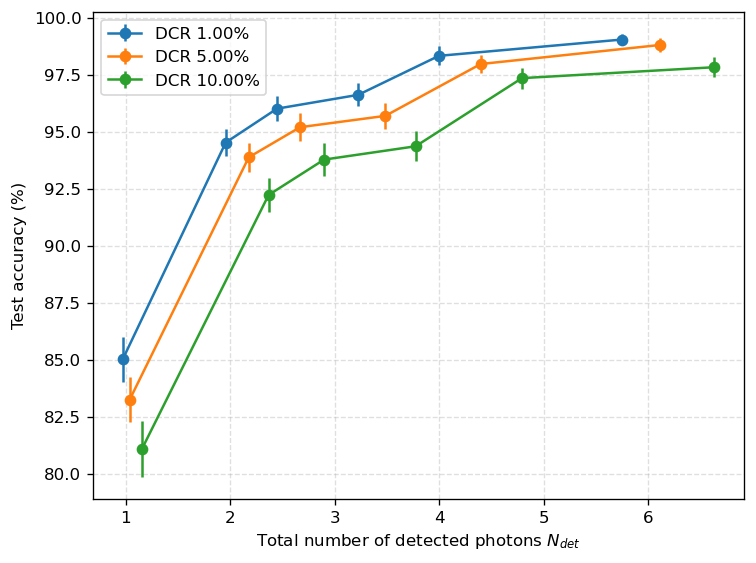

In [21]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_accuracy'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# Fiber
## Load the data

In [22]:
data = np.load(dataPath / 'fiber_4k1k.npz')
X = torch.from_numpy(data['X'])
y = torch.from_numpy(data['y'])
X.shape, y.shape

(torch.Size([5000, 1, 64, 64]), torch.Size([5000]))

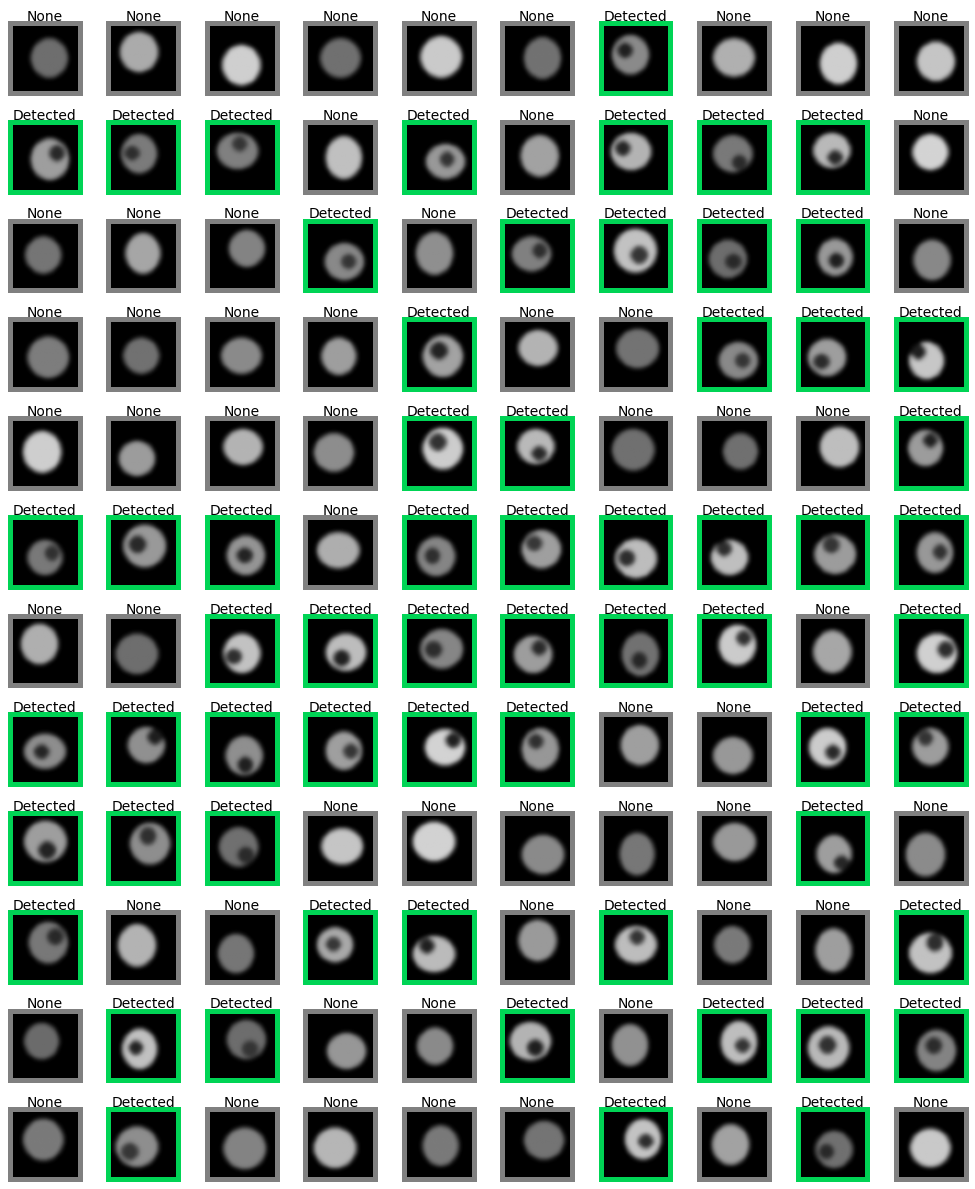

In [23]:
from matplotlib import rcParams
rcParams['axes.titlepad'] = 0 
np.random.seed(10)

nx, ny = 12,10
fig, axs = plt.subplots(nx, ny, figsize=(ny, nx))
namestr = ['None', 'Detected', 'Mitochondria']
for i in range(nx):
    for j in range(ny):
        ax = axs[i, j]
        ind = np.random.randint(X.shape[0])
        im = ax.imshow(X[ind].reshape(64,64), vmin=0, vmax=1.2,cmap='binary_r',aspect='equal')
            
        ax.set_xticks([])
        ax.set_yticks([])
        
        for sp in ax.spines:
            ax.spines[sp].set_color('#00d455' if y[ind] else 'gray')
            ax.spines[sp].set_linewidth(3.6)

        ax.set_title(f'{namestr[y[ind]]}',fontsize=10)

plt.tight_layout()

In [24]:
from torch.utils.data import TensorDataset, DataLoader

input_size = np.prod(X.shape[-2:])
num_classes = 2

n_samples = X.shape[0]
train_size = int(0.8 * n_samples)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size].type(torch.long), y[train_size:].type(torch.long)

test_dataset = TensorDataset(X_val, y_val)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)


## Load the models

In [25]:
from PANS_linear import PANS_passive
import ast

device = 'cpu'
fiberPath = modelPath / 'fiber'

models = {}
dfs = []
for f in os.listdir(fiberPath):
    if f.startswith(f'fiber4k1k64_N'):
        N = int(f.split('_')[1][1:])
        dfs.append(N)
        print(N,f)

        n_chans = []
        n_kers = 0
        pool_size = 2      
        fc_config = ast.literal_eval(f.split('_')[2].split('.')[0][2:])  
        pool_type = 'avg'
        if_logsoft = True

        model = PANS_passive(n_input=input_size, n_output=num_classes, n_feature=N, pool_type=pool_type, conv_channels=n_chans, conv_kernel=n_kers, pool_size=pool_size, fc_units=fc_config, use_feature_batchnorm=True,use_logsoft=if_logsoft).to(device)

        model.load_state_dict(torch.load(fiberPath / f, map_location=device))
        model.to(device)
        model.eval()
        models[N] = model

dfs.sort()
dfs

2 fiber4k1k64_N2_fc[512].pth
4 fiber4k1k64_N4_fc[1024].pth
8 fiber4k1k64_N8_fc[512].pth
3 fiber4k1k64_N3_fc[512].pth
5 fiber4k1k64_N5_fc[512].pth


[2, 3, 4, 5, 8]

## Simulation results

In [26]:
import pandas as pd
n_T = 100
temp_results = []

for dcr in [0.01,0.05,0.1]:
    print('\nDark Count Rate:\t',dcr)

    for df in dfs:
        model = models[df]

        photon_count = 0
        acc_arr = np.zeros((n_T))
        for data, target in test_loader:
            data = data.to(device).reshape(data.shape[0],-1)*0.9
            target = target.to(device)
            
            photon_count += model.get_acts(data).sum().item()+df*dcr*data.shape[0]

            for j in range(n_T):
                output = model.robust_test(data,dcr=dcr,n_rep=1)
                pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
                correct = pred.eq(target.data.view_as(pred)).cpu().sum()
                acc_arr[j] += correct
            # break

        acc_arr = acc_arr / float(len(test_dataset))
        photon_count = photon_count / float(len(test_dataset))
        mean_acc = 100. * acc_arr.mean()
        std_dev = 100. * acc_arr.std()

        # append the results to DataFrame
        temp_results.append({'d_f': df, 'dcr':dcr, 'mean_accuracy': mean_acc, 'std_dev': std_dev, 'det_photon_count': photon_count})
        # pcs.append(actv)
        # accms.append(mean_acc)
        # accss.append(std_dev)

        print(f"Photon count {photon_count:.4g} \t{np.round(mean_acc,2):.2f} ± {np.round(std_dev,2):.2f}% (dcr {dcr}, repeat {n_T})")

results_df = pd.concat([pd.DataFrame([i]) for i in temp_results], ignore_index=True)



Dark Count Rate:	 0.01
Photon count 0.85 	95.79 ± 0.64% (dcr 0.01, repeat 100)
Photon count 1.334 	97.03 ± 0.49% (dcr 0.01, repeat 100)
Photon count 2.151 	98.65 ± 0.37% (dcr 0.01, repeat 100)
Photon count 3.379 	99.57 ± 0.21% (dcr 0.01, repeat 100)
Photon count 6.259 	99.48 ± 0.22% (dcr 0.01, repeat 100)

Dark Count Rate:	 0.05
Photon count 0.944 	92.33 ± 0.81% (dcr 0.05, repeat 100)
Photon count 1.446 	96.51 ± 0.44% (dcr 0.05, repeat 100)
Photon count 2.307 	97.82 ± 0.48% (dcr 0.05, repeat 100)
Photon count 3.578 	98.86 ± 0.35% (dcr 0.05, repeat 100)
Photon count 6.559 	98.82 ± 0.30% (dcr 0.05, repeat 100)

Dark Count Rate:	 0.1
Photon count 1.052 	87.81 ± 1.04% (dcr 0.1, repeat 100)
Photon count 1.6 	95.34 ± 0.60% (dcr 0.1, repeat 100)
Photon count 2.508 	96.12 ± 0.65% (dcr 0.1, repeat 100)
Photon count 3.832 	97.16 ± 0.51% (dcr 0.1, repeat 100)
Photon count 6.962 	97.60 ± 0.45% (dcr 0.1, repeat 100)


In [27]:
results_df.to_pickle(savePath / 'fiber_passive_sim.npy')
results_df

,d_f,dcr,mean_accuracy,std_dev,det_photon_count
0,2,0.01,95.792,0.643223,0.850
1,3,0.01,97.028,0.488279,1.334
2,4,0.01,98.654,0.369708,2.151
3,5,0.01,99.573,0.207776,3.379
4,8,0.01,99.478,0.218897,6.259
5,2,0.05,92.334,0.805509,0.944
6,3,0.05,96.515,0.439631,1.446
7,4,0.05,97.817,0.481675,2.307
8,5,0.05,98.863,0.348326,3.578
9,8,0.05,98.824,0.303684,6.559


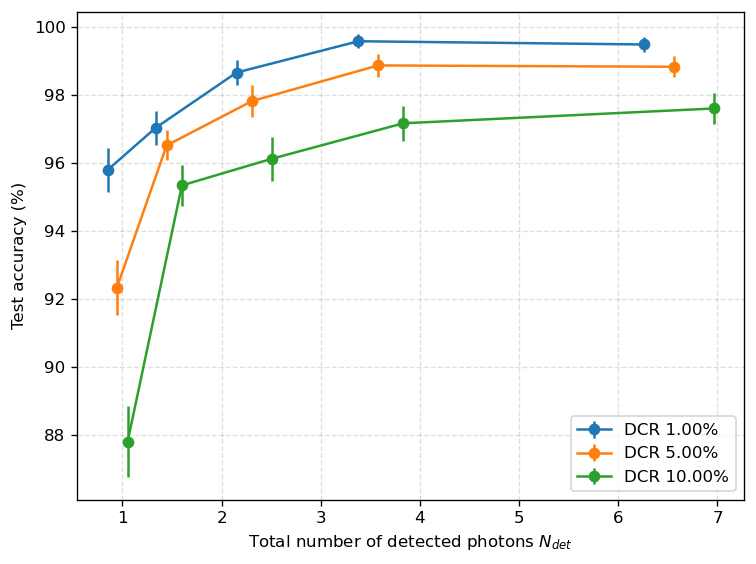

In [28]:
# Plot N vs accuracy with errorbars (uses existing variables in the notebook)
import matplotlib.pyplot as plt

k_val = 1

fig, ax = plt.subplots(dpi=120)

for dcr in results_df['dcr'].unique():
    the_df = results_df[results_df['dcr'] == dcr].sort_values('d_f')
    plt.errorbar(the_df['det_photon_count'],the_df['mean_accuracy'],yerr=the_df['std_dev'],fmt='-o',label=f'DCR {dcr*100:.2f}%')

plt.xlabel(r'Total number of detected photons $N_{det}$')
plt.ylabel('Test accuracy (%)')

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()